In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
sns.set_context("paper")
sns.set_style("ticks");
colors = sns.color_palette()

# ME 308 - Activity 02 - Proper Orthogonal Decomposition

## Instructions

+ **How to run this activity on Google Colab:** Just click [here](https://colab.research.google.com/github/ebilionis/core-me-data-science-activities-public/blob/master/me274/activity_01.ipynb) if you are not already there.
+ **How to turn this activity in:** Please submit the activity as a regular homework assignment.
+ **How to turn the activity to a PDF file:** When you open it on Google Colab, and you are done with your work, just do: File->Print->Save as PDF. Some figures may be misaligned. That's fine.
+ **Save your version of the activity on your Google Drive:**
Google Colab will delete your work once you close the browser. To save a copy to your Google Drive, do:
File->Save a copy in Drive
+ **Typing math:** You can use LaTeX to format your math. Double click on any math cell to see the raw LaTeX code. Google Colab can help you do this using generative AI.

## Sources and Further Reading
+ Professor Bilionis's [online textbook](https://predictivesciencelab.github.io/advanced-scientific-machine-learning/hup/funcin/02_svd.html)
+ Professor Bruton's [YouTube series on SVD and PCA](https://youtube.com/playlist?list=PLMrJAkhIeNNSVjnsviglFoY2nXildDCcv&si=Mtlegpv23T7IK5S6)
+ [Code](https://github.com/pmocz/latticeboltzmann-python) for Lattice Boltzmann method. Special thanks to Abhiskek Singh in Professor Vlachos's group for demonstrating the simulation method and setting up the POD code.

## Engineering Objective:
The objective of this activity is to learn how to use the proper orthogonal decomposition (POD) method to reduce the dimensionality of a dataset. The POD method is a powerful tool for analyzing and reducing the complexity of high-dimensional data, and it is widely used in engineering and scientific applications.

### Part 0: Review of Basic Linear Algebra

**Tutorial:**

In this activity, we will be using the Singular Value Decomposition (SVD) method to perform the proper orthogonal decomposition (POD) of a dataset. In case you have not seen SVD before, we will review some basic linear algebra concepts before moving SVD. 

First we will review basic matrix operations. Recall that a matrix is a rectangular array of numbers. A matrix with m rows and n columns is called an m x n matrix. The transpose of a matrix A, denoted by A^T, is obtained by interchanging its rows and columns. For example, if A is a 2 x 3 matrix:

In [2]:
A = np.array([[1, 2], [3, 4], [5, 6]])
print(f'The shape of A is {A.shape}')
print(f'A is:\n{A}')

The shape of A is (3, 2)
A is:
[[1 2]
 [3 4]
 [5 6]]


We can return its transpose as follows:

In [3]:
A_transpose = A.T
print(f'The shape of A_transpose is {A_transpose.shape}')
print(f'A_transpose is:\n{A_transpose}')

The shape of A_transpose is (2, 3)
A_transpose is:
[[1 3 5]
 [2 4 6]]


Recall that matrix multiplication is defined as follows: if A is an m x n matrix and B is an n x p matrix, then the product AB is an m x p matrix. The (i,j) entry of the product AB is given by:

$$
(AB)_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj}
$$

where $A_{ik}$ is the entry in the i-th row and k-th column of $A$, and $B_{kj}$ is the entry in the k-th row and j-th column of $B$. Matrix multiplication is not commutative, meaning that $AB$ is not necessarily equal to $BA$.

Let's see how this works in practice.

In [4]:
B = np.ones((2, 2))
print(f'The shape of B is {B.shape}')
print(f'B is:\n{B}')

# The dot product of A and B
C = np.dot(A, B)
print(f'The shape of C is {C.shape}')
print(f'C is:\n{C}')

The shape of B is (2, 2)
B is:
[[1. 1.]
 [1. 1.]]
The shape of C is (3, 2)
C is:
[[ 3.  3.]
 [ 7.  7.]
 [11. 11.]]


**Question:**

Now I want you to find $D$ such that it is the matrix product of $A^T$ and $B$. You can do this by using the `@` operator in Python or the `dot` function in NumPy.

In [5]:
# YOUR CODE HERE

In [6]:
# Solution:

D = np.dot(B, A_transpose)
print(f'The shape of D is {D.shape}')
print(f'D is:\n{D}')

The shape of D is (2, 3)
D is:
[[ 3.  7. 11.]
 [ 3.  7. 11.]]


I also want to introduce the concept of orthogonality. Two vectors $u$ and $v$ are said to be orthogonal if their dot product is zero:

$$
u \cdot v = \sum_{i=1}^{n} u_i v_i = 0
$$

where $u_i$ and $v_i$ are the components of the vectors $u$ and $v$, respectively. If two vectors are orthogonal, they are perpendicular to each other in the Euclidean space.
In Python, we can check if two vectors are orthogonal by computing their dot product and checking if it is zero.

In [7]:
u = np.array([1, 0])
v = np.array([0, 1])

# The dot product of u and v
dot_product = np.dot(u, v)
print(f'The dot product of u and v is {dot_product}')

The dot product of u and v is 0


Two matrices are said to be orthogonal if their columns are orthonormal, meaning that the dot product of each pair of columns is zero and the norm of each column is one. In other words, if $A$ is an m x n matrix, then $A$ is orthogonal if:

$$
A^T A = A A^T = I
$$

where $I$ is the identity matrix. Notice how for $A^T A = A A^T$, the matrix must be square. In Python, we can check if a matrix is orthogonal by computing the product of its transpose and itself and checking if it is equal to the identity matrix.

In [8]:
# Construct a nontrivial 3x3 orthogonal matrix
A = np.array([[3/5, -4/5, 0],
              [4/13, 3/13, -12/13],
              [48/65, 36/65, 25/65]])

A_transpose = A.T

dot_product = np.dot(A, A_transpose)
print(f'The dot product of A and A_transpose is \n{dot_product}')

The dot product of A and A_transpose is 
[[ 1.00000000e+00 -1.02482125e-17 -3.56979403e-17]
 [-1.02482125e-17  1.00000000e+00 -2.62774680e-18]
 [-3.56979403e-17 -2.62774680e-18  1.00000000e+00]]


You can see that we are getting some rounding errors, but this is essentially the identity matrix. 

**Question:**

Compute the following matrix product:

$$
A^T A
$$

and see if it is equal to the identity matrix, try rounding it for a nice looking output


In [9]:
# YOUR CODE HERE

In [10]:
# Solution:

dot_product = np.dot(A_transpose, A)
print(f'The dot product of A_transpose and A is \n{np.round(dot_product, 3)}')

The dot product of A_transpose and A is 
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]


### Part 1: Eigendecomposition of a Matrix

**Tutorial:**

In this part, we will be using the eigendecomposition of a matrix to find the principal components of a dataset.

First, let's review the concept of eigenvalues and eigenvectors.

A matrix $A$ is said to be symmetric if $A^T = A$. The eigenvalues of a matrix are the scalars $\lambda$ such that:
$$
A v = \lambda v
$$
where $v$ is a non-zero vector called the eigenvector.
The eigenvalues and eigenvectors of a matrix can be computed using the `numpy.linalg.eig` function in NumPy. 

In [11]:
# generate a 3x3 symmetric matrix
A = np.array([[1, 2, 3],
              [2, 4, 5],
              [3, 5, 6]])

eigenvalues, eigenvectors = np.linalg.eig(A)
print(f'The eigenvalues of A are {eigenvalues}')
print(f'The eigenvectors of A are:\n{eigenvectors}')


The eigenvalues of A are [11.34481428 -0.51572947  0.17091519]
The eigenvectors of A are:
[[-0.32798528 -0.73697623  0.59100905]
 [-0.59100905 -0.32798528 -0.73697623]
 [-0.73697623  0.59100905  0.32798528]]


We can collect the eigenvalues to be the diagonal elements of a diagonal matrix $\Lambda$, and the eigenvectors are the columns of the matrix $V$ such that:

$$
A = V \Lambda V^T
$$

This is called the eigendecomposition of the matrix $A$. 

In [12]:
print(f'Lambda = {np.diag(eigenvalues)}')
print(f'\nV = {eigenvectors}')
print(f'\nV^T = {eigenvectors.T}')

Lambda = [[11.34481428  0.          0.        ]
 [ 0.         -0.51572947  0.        ]
 [ 0.          0.          0.17091519]]

V = [[-0.32798528 -0.73697623  0.59100905]
 [-0.59100905 -0.32798528 -0.73697623]
 [-0.73697623  0.59100905  0.32798528]]

V^T = [[-0.32798528 -0.59100905 -0.73697623]
 [-0.73697623 -0.32798528  0.59100905]
 [ 0.59100905 -0.73697623  0.32798528]]


**Question:**

Reconstruct the matrix $A$ using the eigendecomposition and the formula above. Find the difference between the original matrix and the reconstructed matrix. Mathmatically this will be zero, though in practice using floating point numbers, you will get some rounding errors.

In [13]:
# YOUR CODE HERE

In [14]:
# Solution:

A_reconstructed = np.dot(eigenvectors, np.dot(np.diag(eigenvalues), eigenvectors.T))
print(f'The reconstructed A is:\n{A_reconstructed}')
print(f'The original A is:\n{A}')
print(f'The difference is:\n{A_reconstructed - A}')

The reconstructed A is:
[[1. 2. 3.]
 [2. 4. 5.]
 [3. 5. 6.]]
The original A is:
[[1 2 3]
 [2 4 5]
 [3 5 6]]
The difference is:
[[ 3.55271368e-15  3.55271368e-15  4.44089210e-15]
 [ 3.55271368e-15 -8.88178420e-16  8.88178420e-16]
 [ 4.88498131e-15  1.77635684e-15  2.66453526e-15]]


### Part 2: Singular Value Decomposition

**Tutorial:**

We are finally ready to learn about the singular value decomposition (SVD) of a matrix. SVD is a generalization of the eigendecomposition to non-square and non-diagonalizable matrices. So any real or complex matrix can be decomposed with SVD!
The SVD of a matrix $A$ is a factorization of the form:

$$
A = U \Sigma V^T
$$

Let me show you an examples before we discuss some of the properties. The SVD can be computed using the `numpy.linalg.svd` function in NumPy.

In [15]:
# Define a non-square matrix (3×4)
A = np.array([
    [1, 2, 3, 4],
    [2, 4, 5, 6],
    [3, 5, 6, 8]
])

# Compute the SVD of B
U, S, Vt = np.linalg.svd(A)

Let's first take a look at the $\Sigma$ matrix, or S as it is called in our code. These are our *singular values*. The command `np.linalg.svd` returns the singular values as a vector but really it is a diagonal matrix. Let's take a look.

In [16]:
print(np.diag(S))

[[15.63705965  0.          0.        ]
 [ 0.          0.55849427  0.        ]
 [ 0.          0.          0.41285529]]


The singular values are the square roots of the eigenvalues of the matrix $A^T A$ or $A A^T$. The singular values are always non-negative and are ordered from largest to smallest. We can confirm this by looking at the square matrix where we took the eigendecomposition. We can check that the singular values from the eigendecomposition match those obtained via the SVD.

In [17]:
A_square = np.array([[1, 2, 3],
              [2, 4, 5],
              [3, 5, 6]])
U_a, S_a, Vt_a = np.linalg.svd(A_square)
print(f'The singular values of A are  \n{np.diag(S_a)}')
eigenvalues, eigenvectors = np.linalg.eig(A_square)
print(f'The eigenvalues of A are \n{eigenvalues}')

The singular values of A are  
[[11.34481428  0.          0.        ]
 [ 0.          0.51572947  0.        ]
 [ 0.          0.          0.17091519]]
The eigenvalues of A are 
[11.34481428 -0.51572947  0.17091519]


Great, everything matches except for the sign, this is because the eigenvalues can be negative, but the singular values are always positive becuase they come from $A^T A$ or $A A^T$ which are always positive semi-definite. Let's next take a look at the $U$ matrix. The columns of $U$ are the left singular vectors of the matrix $A$. They are calculated from the eigenvectors of $A A^T$, we can verify this by it being the same dimension. The left singular vectors are orthonormal, meaning that they are orthogonal and have unit length. We can check this by taking the dot product of the columns of $U$ and checking if it is equal to the identity matrix.

In [18]:
print(f'The shape of A A^T is {np.dot(A, A.T).shape}')
print(f'The shape of U is {U.shape}')
U_orthogonal = np.dot(U.T, U)
print(f'The dot product of U^T and U is \n{np.round(U_orthogonal, 3)}')

The shape of A A^T is (3, 3)
The shape of U is (3, 3)
The dot product of U^T and U is 
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]


The matrix $V$ is the right singular vectors of the matrix $A$. They are calculated from the eigenvectors of $A^T A$, we can verify this by it being the same dimension. The right singular vectors are also orthonormal, meaning that they are orthogonal and have unit length. We can check this by taking the dot product of the columns of $V$ and checking if it is equal to the identity matrix.

In [19]:
print(f'The shape of A^T A is {np.dot(A.T, A).shape}')
print(f'The shape of V^T is {Vt.shape}')
Vt_orthogonal = np.dot(Vt, Vt.T)
print(f'The dot product of V^T and V is \n{np.round(Vt_orthogonal, 3)}')

The shape of A^T A is (4, 4)
The shape of V^T is (4, 4)
The dot product of V^T and V is 
[[ 1.  0. -0. -0.]
 [ 0.  1. -0.  0.]
 [-0. -0.  1.  0.]
 [-0.  0.  0.  1.]]


A very helpful tool is the *truncated SVD*. The truncated SVD is a low-rank approximation of the matrix $A$. It is obtained by keeping only the first $k$ singular values and their corresponding singular vectors. Given as

$$
A \approx A_k = U_k \Sigma_k V_k^T
$$

where $U_k$ and $V_k$ are the matrices containing the first $k$ columns of $U$ and $V$, respectively, and $\Sigma_k$ is the diagonal matrix containing the first $k$ singular values. Because we arrange the singular values in descending order, we can keep the first $k$ singular values and their corresponding singular vectors to obtain a low-rank approximation of the matrix $A$. The truncated SVD is useful for reducing the dimensionality of the data and for noise reduction. Let's look at a quick example of the usage of truncated SVD in image compression. I will download it for you.

In [20]:
# If you are working on Google Colab run this to download the image:
!curl -O "https://raw.githubusercontent.com/PredictiveScienceLab/advanced-scientific-machine-learning/main/book/hup/funcin/neom-DMGDdksVoWI-unsplash.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  751k  100  751k    0     0  5133k      0 --:--:-- --:--:-- --:--:-- 5147k


Let's take a look at the image

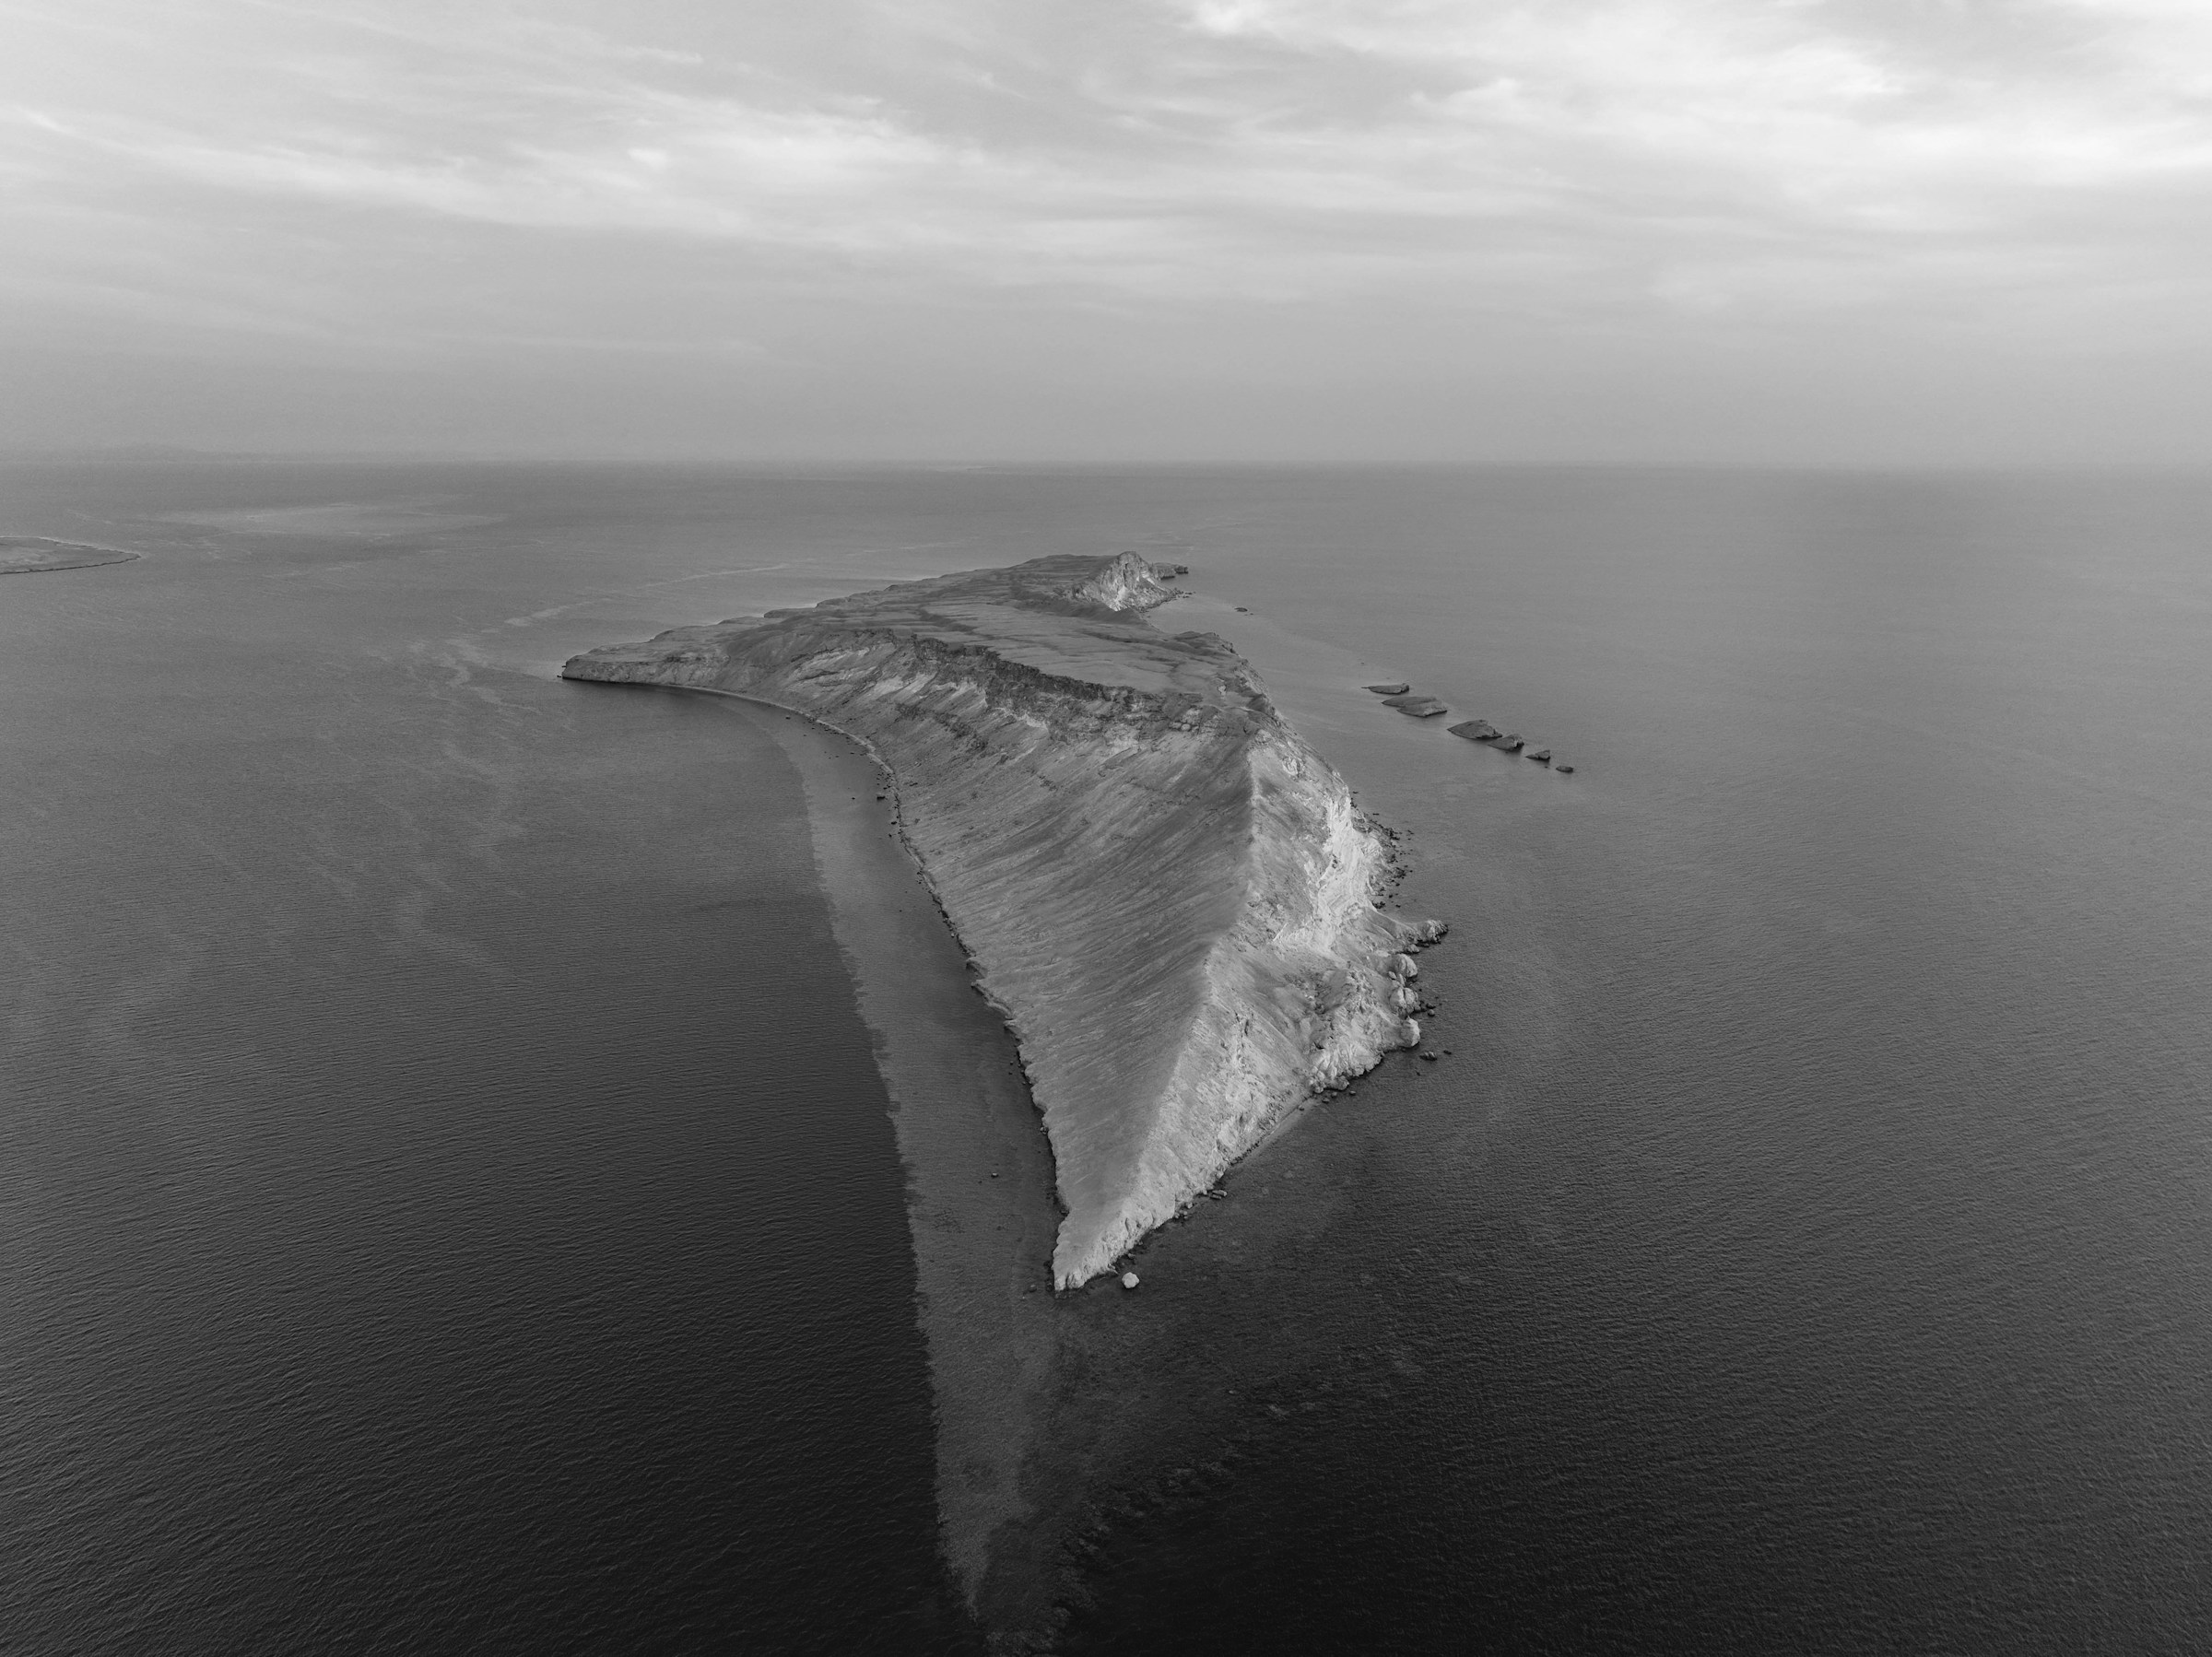

In [21]:
from PIL import Image
with open("neom-DMGDdksVoWI-unsplash.jpg", "rb") as f:
    img = Image.open(f)
    img = img.convert("L")  # convert to grayscale
img

In [22]:
X = np.array(img)
print(f'The shape of X is {X.shape}')

The shape of X is (1798, 2400)


So our task is to reduce the rank of the image by keeping only the first $k$ singular values and their corresponding singular vectors. We can do this by using the `numpy.linalg.svd` function and then reconstructing the image using the truncated SVD.

In [23]:
U, S, Vt = np.linalg.svd(X)

How do we know how many singular values to keep? Let's take a look at the singular values and see how they decay.

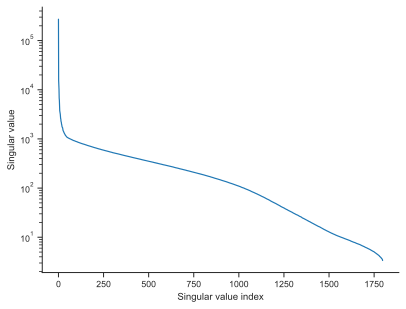

In [24]:
fig, ax = plt.subplots()
ax.plot(S)
ax.set(yscale='log', xlabel="Singular value index", ylabel="Singular value")
sns.despine()

You can see that the singular values decay rapidly, meaning that we capture most of the information in the image with the largest singular values. See what happens when we keep different number of singular values

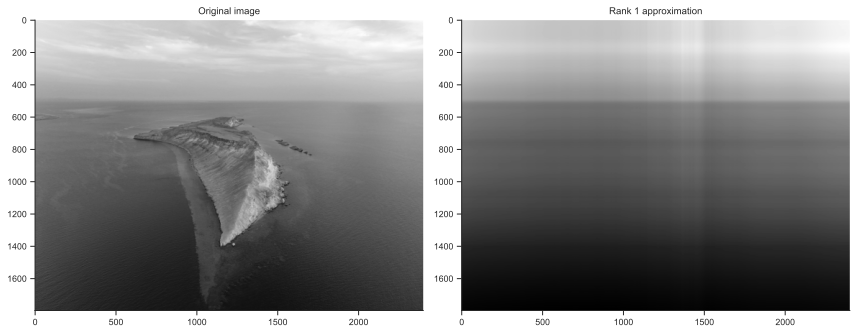

In [25]:
num_s = 1
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(X, cmap='gray')
axes[0].set_title("Original image")

rank_approx = U[:, :num_s] @ np.diag(S[:num_s]) @ Vt[:num_s, :]
axes[1].imshow(rank_approx, cmap='gray')
axes[1].set_title(f"Rank {num_s} approximation")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()


Okay so with just one singular value, we can see that we have an image of the sea with a horizon. I will show you the image with just 20 of the 1798 singular values.

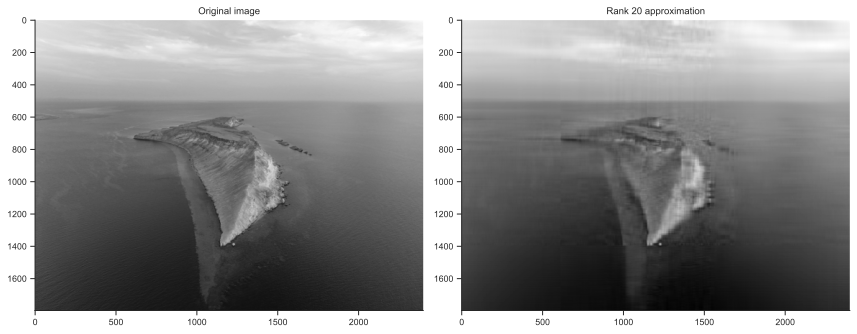

In [26]:
num_s = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(X, cmap='gray')
axes[0].set_title("Original image")
rank_approx = U[:, :num_s] @ np.diag(S[:num_s]) @ Vt[:num_s, :]
axes[1].imshow(rank_approx, cmap='gray')
axes[1].set_title(f"Rank {num_s} approximation")
for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

With 10 singular values with can see a blury image with the general shape of our object. The benefit of this is that we can compress the image by storing only the first $k$ singular values and their corresponding singular vectors. See the difference in how many numbers we need to store.

In [27]:
original_pixes = X.size
reconstructed_pixes = U[:, num_s].size + S[:num_s].size + Vt[:num_s, :].size
pixel_fraction = reconstructed_pixes / original_pixes
print(f'The number of pixels that we need to store for the original image is {original_pixes}')
print(f'The number of pixels that we need to store in the reconstructed image is {reconstructed_pixes}')
print(f'The fraction of pixels that we need to store in the reconstructed image is {pixel_fraction:.2%}')

The number of pixels that we need to store for the original image is 4315200
The number of pixels that we need to store in the reconstructed image is 49818
The fraction of pixels that we need to store in the reconstructed image is 1.15%



A typical choice is to keep the number of singular values that capture some percentage of the total energy of the image. The total energy is given by the sum of the squares of the singular values:

$$
\frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^n \sigma_i^2} \geq 0.999
$$

where $\sigma_i$ are the singular values, k is the number of singular values we keep, and n is the total number of singular values. 

**Question:**

Calculate k such that this condition is satisfied.
Print out the value of k and do the side by side reconstruciton with the original image similar to the example above.

In [28]:
# YOUR CODE HERE!

The number of singular values needed to explain 0.999% of the variance is 269


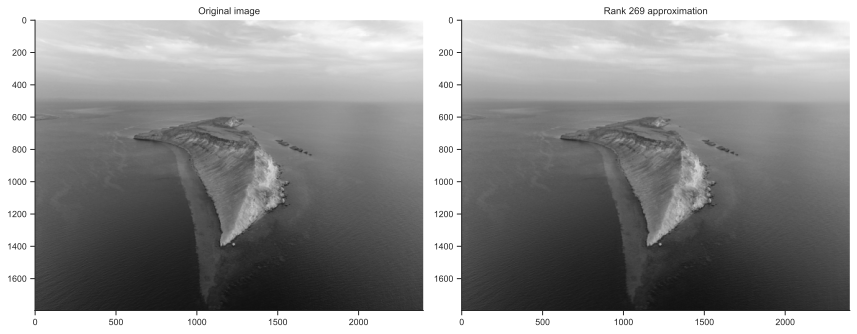

In [29]:
# Solution:

desired_percent = 0.999

cumulative_var = np.cumsum(S**2) / np.sum(S**2)
my_k = np.argmax(cumulative_var > desired_percent)

print(f'The number of singular values needed to explain {desired_percent}% of the variance is {my_k}')

my_k = 269

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(X, cmap='gray')
axes[0].set_title("Original image")
rank_approx = U[:, :my_k] @ np.diag(S[:my_k]) @ Vt[:my_k, :]
axes[1].imshow(rank_approx, cmap='gray')
axes[1].set_title(f"Rank {my_k} approximation")
for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Wow, the reconcstructed image looks identifcal to the the original image to my eye, but we have a significant reduction in the amount of data we need to store. 

### Part 3: Principal Component Analysis

**Tutorial:**

Principal Component Analysis (PCA) is at the heart of many dimensionality reduction techniques, which helps us simplify complex, high-dimensional data and extract the most important features. Mathematically, PCA is a linear transformation that projects the data down to a lower dimensional space to find a set of orthogonal basis vectors that capture the most variance in the data. It does this by finding the sequence of orthogonal axes—called principal components—onto which the original data are projected so that each successive axis captures the maximum remaining variance. By retaining only the first few components, we obtain a lower‑dimensional representation that preserves as much of the dataset’s structure as possible, filtering out noise and redundancy in the process. Really, this is just SVD in disguise! Our principal components are the left singular vectors of the data matrix, and the singular values are the square roots of the eigenvalues of the covariance matrix.

Let's start with synthetically generated scatter plot data.

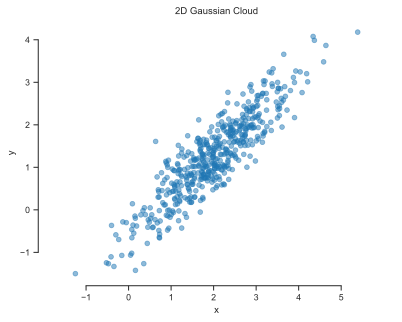

In [30]:
# Generate correlated 2D Gaussian data
mean = [2, 1.25]
cov = [[1.0, 0.9],
       [0.9, 1.0]]  # Covariance matrix introduces correlation
np.random.seed(42)
data = np.random.multivariate_normal(mean, cov, size=500)

# Separate components for plotting
x = data[:, 0]
y = data[:, 1]

# Plot the scatter
plt.figure()
plt.scatter(x, y, alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('2D Gaussian Cloud')
plt.axis('equal')
sns.despine(trim=True)  
plt.show()

An important step of PCA is to center the data before we perform our SVD step. If we don't do this, the first principal component will be along the direction of the mean of the data, not the direction of maximum variance.

$$
\overline{X} = \langle x_i \rangle = \frac{1}{N} \sum_{i=1}^N x_i
$$

We can then simply subtract the mean of each component of the data from each data point to center the data.

$$
X_c = X - \overline{X}
$$

We can now perform our SVD step on the centered data to find our principal components.

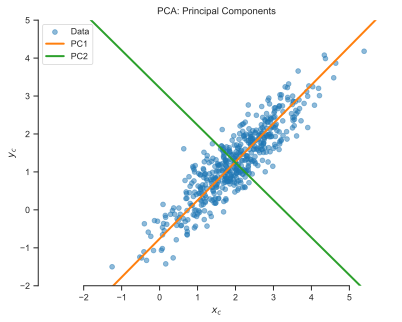

In [31]:
# Calculated the empirical mean of the data
mean_data = np.mean(data, axis=0)

# Center the data
X_c = data - mean_data

# Perform the SVD step
U, S, Vt = np.linalg.svd(X_c)

# Principal component directions (rows of Vt) and scaled arrows
pc1 = Vt[0]
pc2 = Vt[1]

# Plot the data and principal components
plt.figure()
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label='Data')
# Plot the principal components as lines
for i, (pc, s, color, label) in enumerate(zip([pc1, pc2], S, [colors[1], colors[2]], ['PC1', 'PC2'])):
    # Line endpoints: mean +/- scaled principal component
    start = mean_data - pc * s 
    end = mean_data + pc * s 
    plt.plot([start[0], end[0]], [start[1], end[1]], color=color, lw=2, label=label)
plt.xlabel(r'$x_c$')
plt.ylabel(r'$y_c$')
plt.title('PCA: Principal Components')
plt.axis('equal')
plt.xlim(-2, 5)
plt.ylim(-2, 5)
plt.legend()
sns.despine(trim=True)  
plt.show()

We have found our orthogonal basis vectors, PC1 and PC2. Our explained variance for a given component can be calculated as the ratio of the variance of the component to the total variance of the data.

$$
\text{var}_1 = \frac{S_1^2}{S_1^2 + S_2^2}
$$





In [32]:
var_1 = S[0]**2 / (S[0]**2 + S[1]**2)
print(f'The variance explained by the first principal component is {100*var_1:.3f}% of the total variance')

The variance explained by the first principal component is 94.756% of the total variance


We can then reduce the dimensionality of our data by projecting onto our first principal component.

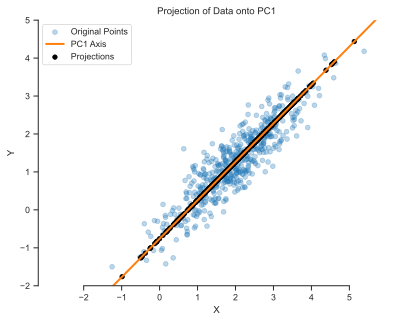

In [33]:
# Compute the "scores" or the scalar values along the PC1 direction
scores = X_c.dot(pc1)

# Reconstruct the 2D projected points along PC1
projected = np.outer(scores, pc1) + mean_data 

# Plot original data, PC1 line, and projections
plt.figure()
plt.scatter(data[:,0], data[:,1], alpha=0.3, label='Original Points')

# Plot the PC1 direction line through the mean
t = np.linspace(-10, 10, 100)
line = mean_data + np.outer(t, pc1)
plt.plot(line[:,0], line[:,1], color=colors[1], lw=2, label='PC1 Axis')

# Plot the projections
plt.scatter(projected[:,0], projected[:,1], color='black', s=20, label='Projections')
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.title('Projection of Data onto PC1')
plt.xlim(-2, 5)
plt.ylim(-2, 5)
sns.despine(trim=True)  
plt.show()

We have reduced our data down to a lower (one) dimension and can analyze it in a new way. This becomes especially helpful and even necessary when we have high-dimensional data on the order of hundreds or thousands of dimensions.

### Part 4: Proper Orthogonal Decomposition

**Given:**

Another name for PCA in the context of fluid dynamics is Proper Orthogonal Decomposition (POD). The same idea of using the SVD to find the principal components of a dataset is used to find the most important *modes* of the flow. 

Imagine we’re running a production line of precision‑engineered pipes and need to ensure each section meets our hydraulic performance specs. We install a radial probe in the pipe, which records the axial velocity at 20 evenly spaced points from the wall to the centerline. Because our extrusion process is very tight, the pipe geometry is virtually identical from batch to batch—so in the ideal case, every velocity profile would be the same parabolic Poiseuille shape.

But in practice we have two problems:

1. Supply fluctuations: slight oscillations in pump pressure introduce low‑frequency “ripples” in the velocity profile (modelled here by a small combination of sinusoidal modes).

2. Sensor noise: our probe has limited precision, so each measurement is contaminated by uncorrelated white noise.

I've generated some synthetic data for that demonstrate the problem. Let's plot some of the sample profiles.

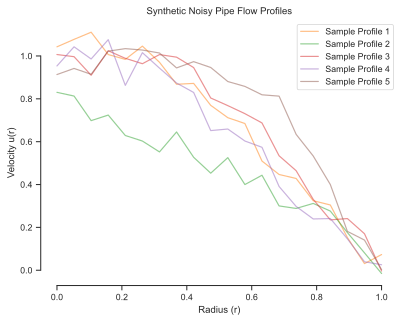

In [34]:
# Parameters for synthetic pipe flow
R = 1.0                      # Pipe radius
n_points = 20                # Spatial resolution along radius
r = np.linspace(0, R, n_points)
m_samples = 100              # Number of flow snapshots

np.random.seed(42)            # For reproducibility
U_max_base = 1.0             # Base maximum velocity
flow_rate_variation = 0.1    # 10% variation in flow rate

# Noise parameters
white_noise_level    = 0.05 # Amplitude of white noise
n_ripples            = 2     # Number of sinusoidal ripple modes
ripple_amp           = 0.1  # Amplitude scale for ripples

# Precompute ripple modes 
ripple_modes = [np.sin((k+1) * np.pi * r / R) for k in range(n_ripples)]
# Initialize data array
data = np.zeros((m_samples, n_points))

# Generate profiles
for i in range(m_samples):
    # Base laminar parabola with flow-rate variation
    U_max_i = U_max_base * (1 + flow_rate_variation * np.random.randn())
    profile = U_max_i * (1 - (r / R)**2)

    # White noise
    profile += white_noise_level * np.random.randn(n_points)

    # Low-frequency sinusoidal ripples
    amps = ripple_amp * np.random.randn(n_ripples)
    ripple = sum(a * mode for a, mode in zip(amps, ripple_modes))
    profile += ripple
    
    # Store
    data[i] = profile

# Plot a subset of sample profiles and the mean profile
plt.figure()
# plt.plot(r, data.mean(axis=0), linewidth=3, color=colors[0], label='Mean Profile')
for i in range(5):  # Plot first 10 samples
    plt.plot(r, data[i], alpha=0.5, color=colors[i+1], label=f'Sample Profile {i+1}')
plt.xlabel('Radius (r)')
plt.ylabel('Velocity u(r)')
plt.title('Synthetic Noisy Pipe Flow Profiles')
plt.legend()
sns.despine(trim=True)  
plt.show()

**Question:**

Center the data and perform SVD.
Plot the first 5 modes.

In [35]:
# YOUR CODE HERE

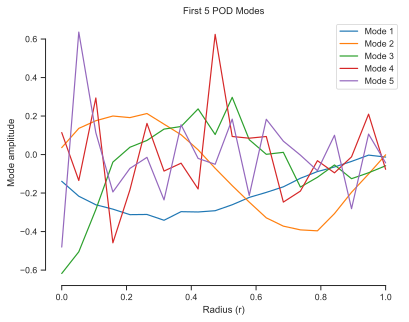

In [36]:
# Center data
mean_profile = np.mean(data, axis=0)
Xc = data - mean_profile

#Perform SVD
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

# Plot the first five POD modes
n_modes = 5
plt.figure()
for i in range(n_modes):
    plt.plot(r, Vt[i], label=f'Mode {i+1}')
plt.xlabel('Radius (r)')
plt.ylabel('Mode amplitude')
plt.title(f'First {n_modes} POD Modes')
plt.legend()
sns.despine(trim=True)  
plt.show()

We can learn a lot about the flow by inspecting our POD modes. The first three modes capture the variation in the water supply and the sinusoidal ripples from our factory floor. Then the fourth mode and beyond is the random noise. If you change the number of ripples, you will see the number of meaninful modes change.

**Question:**

Visualize the explained variance ratio as a function of the number of modes.

In [37]:
# YOUR CODE HERE

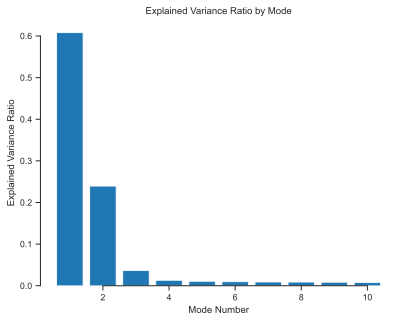

In [38]:
# Explained variance
explained_var = S**2 / (m_samples - 1)
explained_var_ratio = explained_var / explained_var.sum()

# Plot explained variance ratio
plt.figure()
plt.bar(np.arange(1, 11), explained_var_ratio[:10])
plt.xlabel('Mode Number')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Mode')
sns.despine(trim=True)  
plt.show()

The confirms what we saw when we plotted the modes, the majority of the variance is captured by the first three modes.

**Question:**

Reconstruct the first sample using the first three modes. Does it look as good when you just use the first mode?

Hint: Reconstruction can be done the same was as we did with the image in the truncated SVD example. Don't forget to add the mean profile back in!

In [39]:
# YOUR CODE HERE

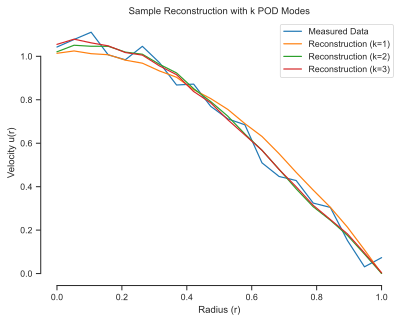

In [40]:
n_modes = 3

# Reconstruction of a sample using k modes to show the improvement in reconstruction as we add more modes

sample_idx = 0  # first sample
plt.figure()
plt.plot(r, data[sample_idx], label='Measured Data')
for k in range(1, n_modes+1):
    recon = mean_profile + (U[sample_idx, :k] * S[:k]) @ Vt[:k, :]
    plt.plot(r, recon, label=f'Reconstruction (k={k})')
plt.xlabel('Radius (r)')
plt.ylabel('Velocity u(r)')
plt.title('Sample Reconstruction with k POD Modes')
plt.legend()
sns.despine(trim=True)  
plt.show()


### Question 5: Time-Dependent Proper Orthogonal Decomposition

**Tutorial:**

To show you the power of POD, we will use it to analyze the vorticity field of a flow past a cylinder. You do not need to answer any questions, but I encourage you to play around with the code and see what kind of reconstructions you can make. 
The data is generated from a Lattice Boltzmann simulation, beyond the scope of the course and assignment. 

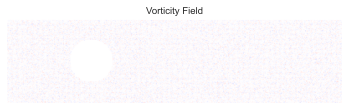

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import PillowWriter
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message="Animation was deleted without rendering anything", category=UserWarning)


"""
Create Your Own Lattice Boltzmann Simulation (With Python)
Philip Mocz (2020) Princeton Univeristy, @PMocz

Simulate flow past cylinder
for an isothermal fluid

"""

"""
Mathematical Background:

1. Lattice Boltzmann Method (LBM):
   - Streaming: f_i(x + c_i, t+1) = f_i(x, t)
   - Collision (BGK model):
       f_i(x, t) = f_i(x, t) - (1/tau) * (f_i(x, t) - f_i^eq(x, t))
     with
       f_i^eq = w_i * rho * [1 + 3(c_i·u) + 9/2 (c_i·u)^2 - 3/2 u^2]
   - Macroscopic quantities:
       rho = sum_i f_i,  u = (sum_i c_i f_i) / rho

"""

# Simulation parameters
Nx = 400         # resolution in x-direction
Ny = 100         # resolution in y-direction
rho0 = 100       # average density
tau = 0.6        # collision timescale
Nt = 1000        # number of timesteps
plot_interval = 10  # record a frame every 10 timesteps

# Lattice parameters (D2Q9)
NL = 9
idxs = np.arange(NL)
cxs = np.array([0, 0, 1, 1, 1, 0, -1, -1, -1])
cys = np.array([0, 1, 1, 0, -1, -1, -1, 0, 1])
weights = np.array([4/9, 1/9, 1/36, 1/9, 1/36, 1/9, 1/36, 1/9, 1/36])

# Directory for results
directory_results = './'
os.makedirs(directory_results, exist_ok=True)

# Initialize distribution function F with small noise and modulation
F = np.ones((Ny, Nx, NL))
np.random.seed(42)
F += 0.01 * np.random.randn(Ny, Nx, NL)
X, Y = np.meshgrid(np.arange(Nx), np.arange(Ny))
F[:,:,3] += 2 * (1 + 0.2 * np.cos(2 * np.pi * X / Nx * 4))
rho = np.sum(F, axis=2)
for i in idxs:
    F[:,:,i] *= rho0 / rho

# Define cylinder boundary: a circular obstacle in the domain
Xgrid, Ygrid = np.meshgrid(np.arange(Nx), np.arange(Ny))
cylinder = (Xgrid - Nx/4)**2 + (Ygrid - Ny/2)**2 < (Ny/4)**2

# Preallocate arrays to record velocity and vorticity for animation
num_frames = Nt // plot_interval + 1
ux_record = np.zeros((Ny, Nx, num_frames))
uy_record = np.zeros((Ny, Nx, num_frames))
vorticity_record = np.zeros((Ny, Nx, num_frames))

frame_counter = 0

# Prepare figure for simulation animation
fig_sim, ax_sim = plt.subplots(figsize=(6, 2))
im_sim = ax_sim.imshow(np.zeros((Ny, Nx)), cmap='bwr', vmin=-0.1, vmax=0.1)
ax_sim.invert_yaxis()
ax_sim.axis('off')
ax_sim.set_title('Vorticity Field')

# Simulation main loop
for it in range(Nt):
    # Streaming: roll F along each lattice direction
    for i, cx, cy in zip(idxs, cxs, cys):
        F[:,:,i] = np.roll(F[:,:,i], shift=cx, axis=1)
        F[:,:,i] = np.roll(F[:,:,i], shift=cy, axis=0)
    
    # Bounce-back boundary condition for the cylinder
    bndryF = F[cylinder, :].copy()
    bndryF = bndryF[:, [0, 5, 6, 7, 8, 1, 2, 3, 4]]
    
    # Compute macroscopic density and velocity
    rho = np.sum(F, axis=2)
    ux = np.sum(F * cxs[np.newaxis, np.newaxis, :], axis=2) / rho
    uy = np.sum(F * cys[np.newaxis, np.newaxis, :], axis=2) / rho
    
    # Collision: relax towards equilibrium distribution
    Feq = np.zeros_like(F)
    for i, cx, cy, w in zip(idxs, cxs, cys, weights):
        cu = cx * ux + cy * uy
        Feq[:,:,i] = rho * w * (1 + 3*cu + 9/2*cu**2 - 3/2*(ux**2 + uy**2))
    F += -(1.0/tau) * (F - Feq)
    
    # Apply bounce-back for the cylinder
    F[cylinder, :] = bndryF
    
    # Record frames every plot_interval timesteps
    if (it % plot_interval == 0) or (it == Nt - 1):
        # Compute vorticity using central differences
        vort = (np.roll(ux, -1, axis=0) - np.roll(ux, 1, axis=0)) - \
               (np.roll(uy, -1, axis=1) - np.roll(uy, 1, axis=1))
        vort[cylinder] = np.nan  # mask out the cylinder
        
        ux_record[:, :, frame_counter] = ux
        uy_record[:, :, frame_counter] = uy
        vorticity_record[:, :, frame_counter] = vort
        
        # Update animation frame
        im_sim.set_data(vort)
        plt.pause(0.001)
        frame_counter += 1

# Assume fig_sim and im_sim have already been created
gif_file = os.path.join(directory_results, 'vorticity_simulation_small.gif')
writer = PillowWriter(fps=30)
with writer.saving(fig_sim, gif_file, dpi=200):
    for i in range(vorticity_record.shape[2]):
        im_sim.set_data(vorticity_record[:, :, i])
        writer.grab_frame()
plt.close(fig_sim)

Here we will focus on the vorticity in the field. Vorticity is defined as the curl of the velocity field:

$$
\boldsymbol{\omega} = \nabla \times \mathbf{u}
$$

Physically, vorticity represents the local spinning motion of the fluid. In regions of high vorticity, fluid elements rotate rapidly—this is often seen in vortices and turbulent flows. Conversely, low vorticity indicates smoother, more laminar flow. Vorticity is crucial for understanding flow separation, vortex shedding, and mixing, which are important in both natural phenomena and engineering applications.

In our simulation of flow past a cylinder, vorticity is generated at the surface of the cylinder due to the no-slip condition, and it evolves downstream as the fluid interacts with the obstacle.

Below is the video of the vorticity evolution in our simulation:

<div style="text-align: center;">
  <img src="vorticity_simulation_small.gif" width="600" height="200" alt="Vorticity Simulation">
</div>



Here we will reshape our simulation into a matrix, where each column is a snapshot in time of the vorticity field. We can then use POD to analyze the flow. We ran the simulation for 1000 time steps and saved every 10th simulation, so we have 100 snapshots.

We can then use POD to analyze the flow.

In [42]:
# Reshape vorticity snapshots into a matrix A of shape (Ny*Nx, num_frames)
snapshots = vorticity_record.reshape(Ny * Nx, -1)
# Replace NaNs (from the cylinder) with 0 for SVD computation
snapshots = np.nan_to_num(snapshots, nan=0.0)

# Compute the SVD: A = U Σ V^T
U, S, Vt = np.linalg.svd(snapshots, full_matrices=False)

The energy of the modes is given by the square of the singular values. We can plot them as usual. Plotting them in log-scale shows us that the first few modes capture most of the energy.

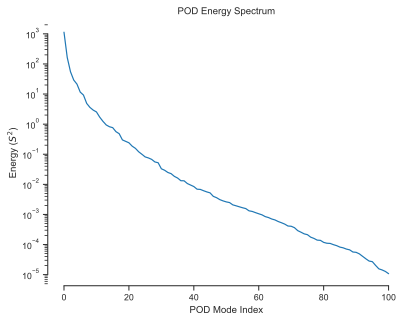

In [43]:
# The temporal coefficients for mode k are: a_k(t) = S[k] * Vt[k, t]
pod_coeff = S[:, np.newaxis] * Vt  # shape: (num_modes, num_frames)

# Plot the energy spectrum of the POD modes
energy = S**2  # Energy associated with each POD mode
plt.figure()
sns.lineplot(x=np.arange(len(energy)), y=energy)
plt.yscale('log')
plt.xlabel('POD Mode Index')
plt.ylabel(r'Energy ($S^2$)')
plt.title('POD Energy Spectrum')
sns.despine(trim=True)
plt.show()

In [44]:
# Define the selected mode indices for uniform spacing.
selected_indices = [0, 10, 20, 30, 40, 50]
num_modes_to_plot = len(selected_indices)

# Extract spatial modes for the selected indices.
pod_modes = [U[:, k].reshape(Ny, Nx) for k in range(max(selected_indices) + 1)]

# Create a figure with a 3x2 grid of subplots to display the evolution of selected modes.
fig_trunc, axes_trunc = plt.subplots(3, 2, figsize=(8, 4.5))
axes_trunc = axes_trunc.flatten()  # flatten to iterate easily
im_list_trunc = []

# Initialize each subplot with the contribution of a single selected mode at the first time step.
for i in range(num_modes_to_plot):
    # Simply plot the evolution of each mode (without cumulative summation).
    field = pod_modes[selected_indices[i]] * pod_coeff[selected_indices[i], 0]
    im = axes_trunc[i].imshow(field, cmap='bwr')
    axes_trunc[i].invert_yaxis()
    axes_trunc[i].axis('off')
    axes_trunc[i].set_title(f'Mode: {selected_indices[i]}', fontsize=10)
    im_list_trunc.append(im)

fig_trunc.suptitle('Temporal Evolution of Selected POD Modes', fontsize=16)
fig_trunc.tight_layout(rect=[0, 0, 1, 0.96])

def update_mode(frame):
    # Update each subplot with the evolution of each selected mode at time "frame"
    for i in range(num_modes_to_plot):
        field = pod_modes[selected_indices[i]] * pod_coeff[selected_indices[i], frame]
        im_list_trunc[i].set_data(field)
        im_list_trunc[i].set_clim(np.min(field), np.max(field))
        axes_trunc[i].set_title(f'Mode: {selected_indices[i]}', fontsize=10)
    return im_list_trunc

# Create the animation using matplotlib.animation.FuncAnimation
anim_trunc = animation.FuncAnimation(fig_trunc, update_mode, frames=vorticity_record.shape[2],
                                     interval=100, blit=False)

my_anim = anim_trunc.to_jshtml()

# Save the animation as a GIF file using PillowWriter.
trunc_anim_file = os.path.join(directory_results, 'pod_modes.gif')
trunc_writer = PillowWriter(fps=30)
with trunc_writer.saving(fig_trunc, trunc_anim_file, dpi=100):
    for frame in range(vorticity_record.shape[2]):
        update_mode(frame)
        trunc_writer.grab_frame()
plt.close(fig_trunc)

print("POD mode evolution animation saved as GIF file.")

POD mode evolution animation saved as GIF file.


This is how the POD modes evolve in time:

<div style="text-align: center;">
  <img src="./pod_modes.gif" width="800" height="300" alt="Vorticity Simulation">
</div>

Notice how the higher modes progressively capture higher frequency features—both in space (smaller, finer structures) and in time (more rapid variations). This indicates that as we move to higher mode indices, the POD extracts the less energetic, more detailed fluctuations of the flow.

Try playing around with the number of modes

In [45]:
n_modes = 5
num_frames = vorticity_record.shape[2]

fig_recon, ax_recon = plt.subplots(figsize=(6, 2))
im_recon = ax_recon.imshow(np.zeros((Ny, Nx)), cmap='bwr')
ax_recon.invert_yaxis()
ax_recon.axis('off')
ax_recon.set_title(f'POD Reconstruction (Rank = {n_modes})')

def update_recon(frame):
    # Reconstruct the vorticity field at the given frame using the first "k" modes.
    recon = np.zeros(Ny * Nx)
    for k in range(n_modes):
        recon += S[k] * U[:, k] * Vt[k, frame]
    recon = recon.reshape(Ny, Nx)
    im_recon.set_data(recon)
    im_recon.set_clim(np.min(recon), np.max(recon))
    return im_recon,

# Create the animation object (if you need a preview, though saving the frames is sufficient)
anim_recon = animation.FuncAnimation(fig_recon, update_recon, frames=num_frames,
                                     interval=100, blit=False)

# Save the animation as a GIF file
recon_anim_file = os.path.join(directory_results, f'pod_reconstruction_{n_modes}.gif')
recon_writer = PillowWriter(fps=30)
with recon_writer.saving(fig_recon, recon_anim_file, dpi=200):
    for frame in range(num_frames):
        update_recon(frame)
        recon_writer.grab_frame()
plt.close(fig_recon)
print(f"POD reconstruction (rank {n_modes}) animation for data saved as GIF file.")

POD reconstruction (rank 5) animation for data saved as GIF file.


Below is a video showcasing the POD reconstructed vorticity fields:

<div style="text-align: center;">
  <img src="pod_reconstruction_5.gif" width="800" height="300" alt="POD Reconstructed Vorticity">
</div>

The reconstructed fields are much clearer—demonstrating that by retaining only the dominant modes, we effectively filter out noise and preserve the key flow dynamics.